<h2 style="color:#9D2449; font-family:'Montserrat', sans-serif; font-size:42px; font-weight:700; margin-top:25px; margin-bottom:12px;">
Correlation 
</h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.linalg import fractional_matrix_power


<h4 style="color:#0F3D36; font-family:'Montserrat', sans-serif; font-size:20px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Carga de datos
</h4>

In [5]:
path = 'https://raw.githubusercontent.com/gonza98kg/Tramites-y-servicios/analysis-indice-tramites/df_esc_A.csv'
df_esc_A = pd.read_csv(path)

df_esc_A.head()

,Tiempo_en_minutos,N_FORMATOS_FINAL,CONTEO_NETO,TraCosto,nivel_digitalizacion
0,-0.189093,-1.0,-0.5,0.0,0.0
1,-0.188873,1.0,3.0,0.0,11.0
2,-0.188435,2.0,4.0,0.0,0.0
3,0.812660,-1.0,0.0,-1.0,0.0
4,-0.126208,1.0,2.5,0.0,0.0


<h4 style="color:#0F3D36; font-family:'Montserrat', sans-serif; font-size:20px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Matriz de correlación
</h4>

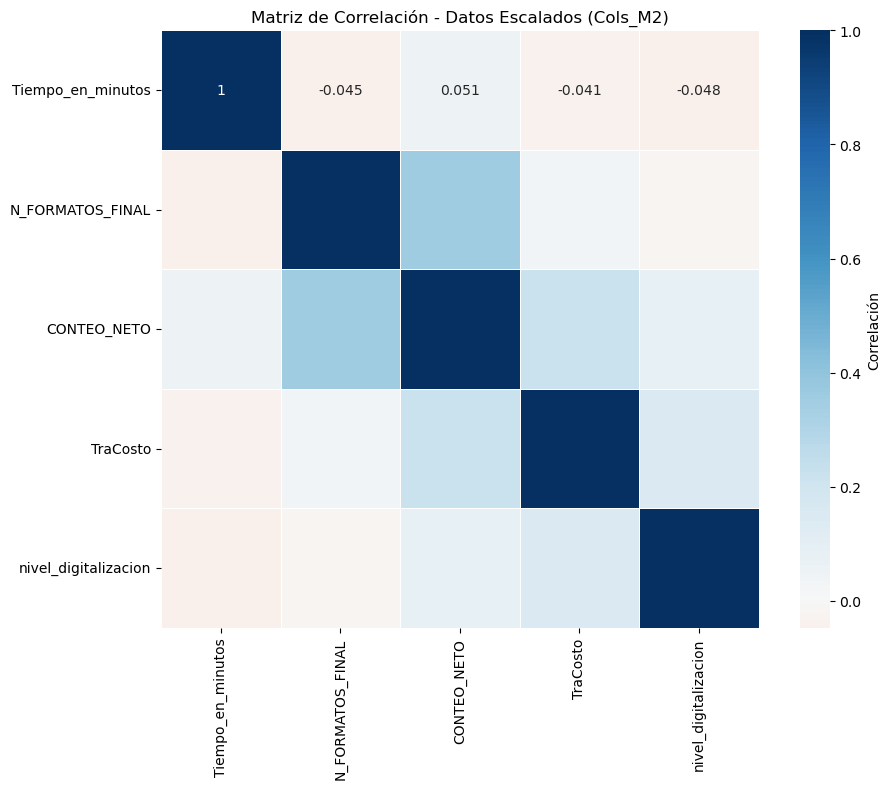

,Tiempo_en_minutos,N_FORMATOS_FINAL,CONTEO_NETO,TraCosto,nivel_digitalizacion
Tiempo_en_minutos,1.000000,-0.044877,0.051111,-0.040834,-0.047609
N_FORMATOS_FINAL,-0.044877,1.000000,0.360923,0.038980,-0.016462
CONTEO_NETO,0.051111,0.360923,1.000000,0.225646,0.081773
TraCosto,-0.040834,0.038980,0.225646,1.000000,0.149677
nivel_digitalizacion,-0.047609,-0.016462,0.081773,0.149677,1.000000


In [7]:
# Matriz de correlación de df_esc_A
corr_matrix_A = df_esc_A.corr()

# Visualizar la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_A, annot=True, cmap='RdBu', center=0, square=True, linewidths=0.5, cbar_kws={'label': 'Correlación'})
plt.title('Matriz de Correlación - Datos Escalados (Cols_M2)')
plt.tight_layout()
plt.show()

# Mostrar la matriz en formato tabla
corr_matrix_A

<h4 style="color:#0F3D36; font-family:'Montserrat', sans-serif; font-size:20px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Cambio de Base
</h4>

Debido a que la matriz de correlación $\mathbb{C}$ es simétrica ($C_{ij}=C_{ji}$) y diagonal, se puede aplicar un cambio de base tal que:

$$\mathbb{A}^T\mathbb{C}\mathbb{A}=\Lambda \tag{1}$$

Donde $\Lambda$ es una matriz de eigenvalores.

Se propone realizar esta metodología a fin de tener otro punto de vista de las variables mediante un cambio de base.

I. Cálculo de los eigenvalores de $\mathbb{C}$

II. Cálculo de los eigenvectores de $\mathbb{C}$

III. Construcción de $\mathbb{A}$

IV. Verificación de $(1)$

V. Normalización

<h4 style="color:#98989A; font-family:'Montserrat', sans-serif; font-size:16px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Obtención de los Eigenvalores
</h4>

Se resuelven las siguientes ecuaciones para determinar los eigenvalores y eigenvectores de la matriz $\mathbb{C}$, respectivamente
$$(\mathbb{C}-\lambda \mathbb{I})=0$$

$$(\mathbb{C}-\lambda \mathbb{I})\mathbf{v}=0$$

In [8]:
eigenvalores, eigenvectores = np.linalg.eigh(corr_matrix_A)

pd.DataFrame(
    eigenvalores, 
    index=[f"λ{i+1}" for i in range(len(eigenvalores))],
    columns=["Eigenvalor"]
).round(2)

,Eigenvalor
λ1,0.58
λ2,0.84
λ3,1.00
λ4,1.11
λ5,1.47


In [17]:
Cols_M2 = [
    'Tiempo_en_minutos', 
    'N_FORMATOS_FINAL', 
    'CONTEO_NETO', 
    'TraCosto',
    'nivel_digitalizacion'
]

eigenvalores, eigenvectores = np.linalg.eigh(corr_matrix_A)

idx = np.argsort(eigenvalores)[::-1]
eigenvalores = eigenvalores[idx]
A = eigenvectores[:, idx]

pd.DataFrame(
    eigenvectores, 
    index=Cols_M2, 
    columns=[f"v{i+1}" for i in range(eigenvectores.shape[1])]
).round(3)

,v1,v2,v3,v4,v5
Tiempo_en_minutos,0.187,0.100,-0.910,-0.355,-0.043
N_FORMATOS_FINAL,0.597,0.253,0.297,-0.443,0.544
CONTEO_NETO,-0.710,0.004,-0.098,-0.201,0.667
TraCosto,0.316,-0.677,-0.205,0.448,0.445
nivel_digitalizacion,0.069,0.684,-0.180,0.661,0.243


<h4 style="color:#98989A; font-family:'Montserrat', sans-serif; font-size:16px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Matriz de eigenvalores
</h4>
Se obtiene la matriz de eigenvalores mediante

$$\Lambda = \mathbb{A}^T\mathbb{C}\mathbb{A}$$

In [22]:
Lambda = A.T @ corr_matrix_A @ A

Lambda.round(2)

,0,1,2,3,4
0,1.47,-0.00,0.0,0.00,-0.00
1,-0.00,1.11,-0.0,-0.00,-0.00
2,0.00,-0.00,1.0,0.00,-0.00
3,0.00,-0.00,0.0,0.84,0.00
4,-0.00,-0.00,0.0,0.00,0.58


<h4 style="color:#98989A; font-family:'Montserrat', sans-serif; font-size:16px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Normalización
</h4>

A partir de $\mathbb{A}$ y $\Lambda$ se construye la matriz de normalización $\mathbb{B}$, definida como:

$$\mathbb{B} = \mathbb{A}\Lambda^{-1/2} \tag{2}$$

La transformación $\Lambda^{-1/2}$ escala cada eigenvector por el inverso de la raíz de su eigenvalor correspondiente, de modo que todas las direcciones quedan con varianza unitaria. Esto se verifica mediante:

$$\mathbb{B}^T\mathbb{C}\mathbb{B} = \mathbb{1} \tag{3}$$

A diferencia del cambio de base $(1)$, donde se obtiene $\Lambda$ en la diagonal, aquí se obtiene la identidad $\mathbb{1}$, lo que implica que las nuevas coordenadas están completamente **decorrelacionadas** y **normalizadas**.

In [20]:
Lambda_inv_sqrt = fractional_matrix_power(Lambda, -0.5)

B = A @ Lambda_inv_sqrt

pd.DataFrame(
    B, 
    index=corr_matrix_A.columns, 
    columns=[f"b{i+1}" for i in range(B.shape[1])]
).round(3)

,b1,b2,b3,b4,b5
Tiempo_en_minutos,-0.035,-0.336,-0.909,0.109,0.246
N_FORMATOS_FINAL,0.448,-0.420,0.297,0.276,0.787
CONTEO_NETO,0.550,-0.191,-0.098,0.004,-0.937
TraCosto,0.367,0.425,-0.205,-0.740,0.417
nivel_digitalizacion,0.200,0.626,-0.180,0.746,0.092


In [21]:
Identity = B.T @ corr_matrix_A @ B
Identity.round(2)

,0,1,2,3,4
0,1.0,-0.0,-0.0,-0.0,0.0
1,0.0,1.0,-0.0,-0.0,0.0
2,0.0,-0.0,1.0,0.0,0.0
3,-0.0,-0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,1.0


In [23]:
varianza = eigenvalores / eigenvalores.sum() * 100

pd.DataFrame({
    "Eigenvalor"         : eigenvalores.round(4),
    "Varianza (%)"       : varianza.round(2),
    "Varianza Acum. (%)": varianza.cumsum().round(2)
}, index=[f"λ{i+1}" for i in range(len(eigenvalores))])

,Eigenvalor,Varianza (%),Varianza Acum. (%)
λ1,1.4711,29.42,29.42
λ2,1.1132,22.26,51.69
λ3,1.0015,20.03,71.72
λ4,0.8391,16.78,88.50
λ5,0.5750,11.50,100.00


<h4 style="color:#0F3D36; font-family:'Montserrat', sans-serif; font-size:20px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Análisis de Resultados
</h4>

**Eigenvalores** — Los cinco eigenvalores obtenidos son $\lambda_1=1.47$, $\lambda_2=1.11$, $\lambda_3=1.00$, $\lambda_4=0.84$, $\lambda_5=0.58$, con suma igual a $5.00$, consistente con la traza de $\mathbb{C}$. Aplicando la regla de Kaiser ($\lambda > 1$), únicamente $\lambda_1$ y $\lambda_2$ son relevantes, sugiriendo que **dos direcciones principales** concentran la información más significativa del espacio de variables.

**Eigenvectores (matriz $\mathbb{A}$)** — Cada columna representa una dirección ortogonal en el espacio de las variables originales:

- **v1** ($\lambda=1.47$): dominado por `CONTEO_NETO` y `N_FORMATOS_FINAL`. Representa la **carga burocrática** del trámite.
- **v2** ($\lambda=1.11$): dominado por `nivel_digitalizacion`. Representa el **nivel de digitalización**.
- **v3** ($\lambda=1.00$): dominado casi en solitario por `Tiempo_en_minutos`. El tiempo es una dimensión **independiente** de las demás variables.
- **v4** ($\lambda=0.84$): tensión entre `TraCosto` y `nivel_digitalizacion` — trámites digitalizados tienden a ser gratuitos.
- **v5** ($\lambda=0.58$): dirección de menor relevancia, mezcla residual de formatos y requisitos.

**Verificación** — Se confirmó que $\mathbb{A}^T\mathbb{C}\mathbb{A}=\Lambda$ y $\mathbb{B}^T\mathbb{C}\mathbb{B}=\mathbb{1}$, validando matemáticamente el cambio de base y la normalización.